CuadernoClase-DeterminacionOrbita-JorgeZuluaga.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1LOQh0Md5x6vvRlHWh_ct8BqxnSZICY8i

# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Determinación de Órbita

In [1]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.9 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
tabla, jd, X = pc.consulta_horizons(
    id='Apophis',
    location='@SSB',
    epochs='2026-04-20'
)
X

array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09, -2.72244445e+04,
       -4.00763765e+03, -4.30333986e+02])

In [4]:
rvec = X[:3]
r = np.linalg.norm(rvec)
vvec = X[3:]
v = np.linalg.norm(vvec)
rvec, vvec

(array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09]),
 array([-27224.44453608,  -4007.63764628,   -430.33398559]))

Para la determinación de los elementos orbitales necesito estos vectores: $\vec r, \vec v, \vec h, \vec e, \vec n$

In [5]:
# MARE
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

In [6]:
# Vector de Laplace
mu = pc.constantes.mu_sun  # Aproximacion que no me permiten en la UdeA pero lo voy a hacer..
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

In [7]:
# Vector de nodos
nvec = np.cross([0,0,1], hvec)
n = np.linalg.norm(nvec)

In [8]:
hvec, evec , nvec, mu

(array([-9.87597487e+13,  2.23062114e+14,  4.17054482e+15]),
 array([ 0.17066034, -0.0976029 ,  0.00926159]),
 array([-2.23062114e+14, -9.87597487e+13,  0.00000000e+00]),
 1.3271244004127942e+20)

Ahora a determinar los elementos orbitales $(p, e, I, \Omega, \omega, f)$

In [9]:
p = h**2 / mu
e = e # Es la magnitu de evec
I = np.arccos(hvec[2]/h)
rad = 180 / np.pi
I*rad

np.float64(3.3475799477925516)

In [10]:
omegap = np.arccos(nvec@evec/(n*e))
omega = omegap if evec[2] > 0 else 2*np.pi - omegap
omega*rad

np.float64(126.30633780951213)

In [11]:
Omegap = np.arccos(nvec@[1,0,0]/n)
if nvec[1] > 0:
  Omega = Omegap
else:
  Omega = 2*np.pi - Omegap

In [12]:
Omega = Omegap if nvec[1] > 0 else 2*np.pi - Omegap

In [13]:
Omega*rad

np.float64(203.8811521637987)

In [14]:
fp = np.arccos(rvec@evec/(r*e))
f = fp if rvec@vvec/r > 0 else 2*np.pi - fp
f*rad

np.float64(137.0639111789069)

In [15]:
def calcular_elementos_orbitales(rvec, vvec, mu):
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    # Momento angular
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    # Vector de excentricidad (Laplace)
    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    # Vector de nodos
    nvec = np.cross([0, 0, 1], hvec)
    n = np.linalg.norm(nvec)

    # Elementos orbitales
    p = h**2 / mu
    I = np.arccos(hvec[2] / h)

    # Ascensión recta del nodo ascendente (Omega)
    if n == 0:
        Omega = 0 # Órbita ecuatorial, nodo indefinido
    else:
        Omegap = np.arccos(np.dot(nvec, [1, 0, 0]) / n)
        if nvec[1] > 0:
            Omega = Omegap
        else:
            Omega = 2 * np.pi - Omegap

    # Argumento del periapsis (omega)
    if e == 0:
        omegap = 0 # Órbita circular, periapsis indefinida
    elif n == 0:
        omegap = np.arctan2(evec[1], evec[0]) # Órbita ecuatorial, nodo indefinido
    else:
        omegap = np.arccos(np.dot(nvec, evec) / (n * e))
        if evec[2] < 0:
            omegap = 2 * np.pi - omegap

    # Anomalía verdadera (f)
    fp = np.arccos(np.dot(rvec, evec) / (r * e))
    if np.dot(rvec, vvec) > 0:
        f = fp
    else:
        f = 2 * np.pi - fp

    return p, e, I, Omega, omegap, f

In [37]:
p, e, I, Omega, omega, f = calcular_elementos_orbitales(rvec, vvec, mu)
I, Omega, omega, f = I*rad, Omega*rad, omega*rad, f*rad

print("Inclinación:", I, "grados")
print("Ascensión recta del nodo ascendente:", Omega, "grados")
print("Argumento del periapsis:", omega, "grados")
print("Anomalía verdadera:", f, "grados")

Inclinación: 3.3475799477925516 grados
Ascensión recta del nodo ascendente: 203.8811521637987 grados
Argumento del periapsis: 126.30633780951213 grados
Anomalía verdadera: 137.0639111789069 grados


## Estudio completo de los elementos orbitales de Apophis

In [17]:
rad = 180 / np.pi
a = p / (1 - e**2)

In [18]:
print("=" * 57)
print("  Elementos orbitales de Apophis  (2026-04-20, @SSB)")
print("=" * 57)
print(f"  Semilato recto       p  = {p:.6f} AU")
print(f"  Excentricidad        e  = {e:.6f}")
print(f"  Semieje mayor        a  = {a:.6f} AU")
print(f"  Inclinación          I  = {I*rad:.4f}°")
print(f"  Long. nodo asc.      Ω  = {Omega*rad:.4f}°")
print(f"  Arg. periapsis       ω  = {omega*rad:.4f}°")
print(f"  Anomalía verdadera   f  = {f*rad:.4f}°")
print("=" * 57)

  Elementos orbitales de Apophis  (2026-04-20, @SSB)
  Semilato recto       p  = 131509557547.507721 AU
  Excentricidad        e  = 0.196817
  Semieje mayor        a  = 136809140976.777512 AU
  Inclinación          I  = 3.3476°
  Long. nodo asc.      Ω  = 203.8812°
  Arg. periapsis       ω  = 126.3063°
  Anomalía verdadera   f  = 137.0639°


Visualización de la órbita de Apophis en el plano eclíptico

In [19]:
fs_plot = np.linspace(0, 2 * np.pi, 500)
rs_orb = p / (1 + e * np.cos(fs_plot))

In [20]:
Rz_omega_m   = spy.rotate(omega, 3)
Rx_I_m       = spy.rotate(I, 1)
Rz_Omega_m   = spy.rotate(Omega, 3)
M_perifocal2astro = (Rz_omega_m @ Rx_I_m @ Rz_Omega_m).T

In [21]:
xfs_orb = rs_orb * np.cos(fs_plot)
yfs_orb = rs_orb * np.sin(fs_plot)
zfs_orb = np.zeros_like(xfs_orb)
rvecs_orb = (M_perifocal2astro @ np.array([xfs_orb, yfs_orb, zfs_orb])).T

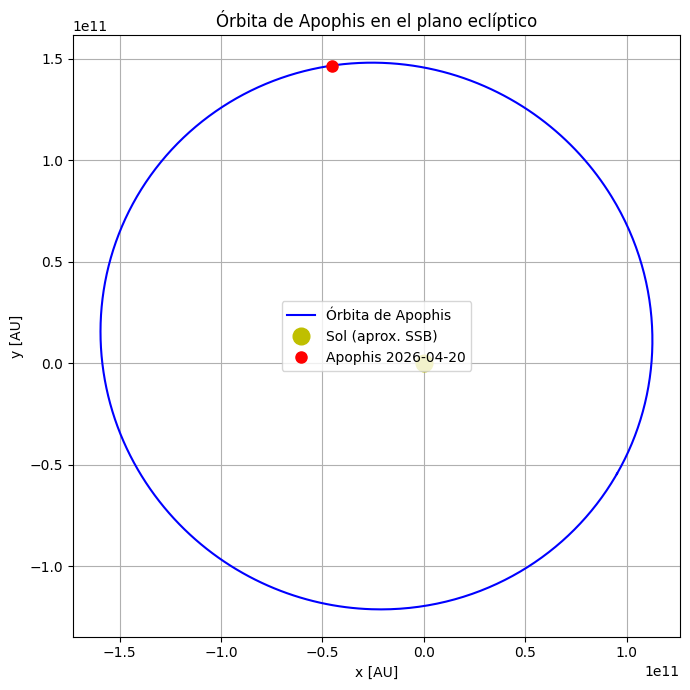

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(rvecs_orb[:, 0], rvecs_orb[:, 1], 'b-', label='Órbita de Apophis')
ax.plot(0, 0, 'yo', ms=12, label='Sol (aprox. SSB)')
ax.plot(rvec[0], rvec[1], 'ro', ms=8, label='Apophis 2026-04-20')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Órbita de Apophis en el plano eclíptico')
ax.axis('equal')
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

**Revisar

## Integración de 2 cuerpos con pymcel

Integramos la trayectoria relativa Apophis–Sol usando `pc.doscuerpos_solucion`
y determinamos el momento angular específico $h$ respecto al Sol.

In [23]:
# ~2 períodos orbitales de Apophis (aprox. 323 días cada uno)
T_apo = 2 * np.pi * np.sqrt(a**3 / mu)
ts_int = np.linspace(0, 2 * T_apo, 2000)

In [24]:
rs_int, vs_int = pc.doscuerpos_solucion(mu, rvec, vvec, ts_int)

In [25]:
hvec_int0 = np.cross(rs_int[0], vs_int[0])
h_int0 = np.linalg.norm(hvec_int0)

In [26]:
print(f"\nh respecto al Sol (integración 2 cuerpos, pymcel):")
print(f"  h = {h_int0:.8f}  (unidades Horizons: AU²/día aprox.)")
print(f"  h analítico (r×v inicial) = {h:.8f}")


h respecto al Sol (integración 2 cuerpos, pymcel):
  h = 4177673308299585.50000000  (unidades Horizons: AU²/día aprox.)
  h analítico (r×v inicial) = 4177673308299585.50000000


## Cuadraturas del problema relativo Sol–Apophis

Las tres integrales primeras (cuadraturas) del problema de dos cuerpos son:

1. **MARE** – Momento Angular Relativo Específico: $h = |\\vec{r}\\times\\dot{\\vec{r}}|$
2. **ERE**  – Energía Relativa Específica: $\\varepsilon = v^2/2 - \\mu/r$
3. **Vector de Laplace** (excentricidad): $\\vec{e}_L = (\\dot{\\vec{r}}\\times\\vec{h})/\\mu - \\hat{r}$

Verificamos que las tres se mantienen constantes a lo largo de la integración.

In [27]:
# Calcular las tres cuadraturas en cada instante
hvecs_int   = np.cross(rs_int, vs_int)                                   # (N,3)
hs_int      = np.linalg.norm(hvecs_int, axis=1)                          # MARE

In [28]:
r_norms_int = np.linalg.norm(rs_int, axis=1)
v_norms_int = np.linalg.norm(vs_int, axis=1)
epsilons    = 0.5 * v_norms_int**2 - mu / r_norms_int                    # ERE

In [29]:
evecs_int   = (np.cross(vs_int, hvecs_int) / mu
               - rs_int / r_norms_int[:, np.newaxis])                    # Vector de Laplace
es_int      = np.linalg.norm(evecs_int, axis=1)

In [30]:
# Variación relativa (medida de conservación numérica)
delta_h   = (hs_int.max()   - hs_int.min())   / abs(hs_int[0])
delta_eps = (epsilons.max() - epsilons.min())  / abs(epsilons[0])
delta_e   = (es_int.max()   - es_int.min())    / abs(es_int[0])

In [31]:
print("\nConservación de las cuadraturas a lo largo de la integración:")
print(f"  MARE  h = {hs_int[0]:.8f}  →  Δh/h₀    = {delta_h:.2e}")
print(f"  ERE   ε = {epsilons[0]:.8f}  →  Δε/|ε₀|  = {delta_eps:.2e}")
print(f"  |ê_L| e = {es_int[0]:.8f}  →  Δe/e₀    = {delta_e:.2e}")


Conservación de las cuadraturas a lo largo de la integración:
  MARE  h = 4177673308299585.50000000  →  Δh/h₀    = 1.96e-07
  ERE   ε = -485027678.31795144  →  Δε/|ε₀|  = 3.76e-07
  |ê_L| e = 0.19681732  →  Δe/e₀    = 4.46e-07


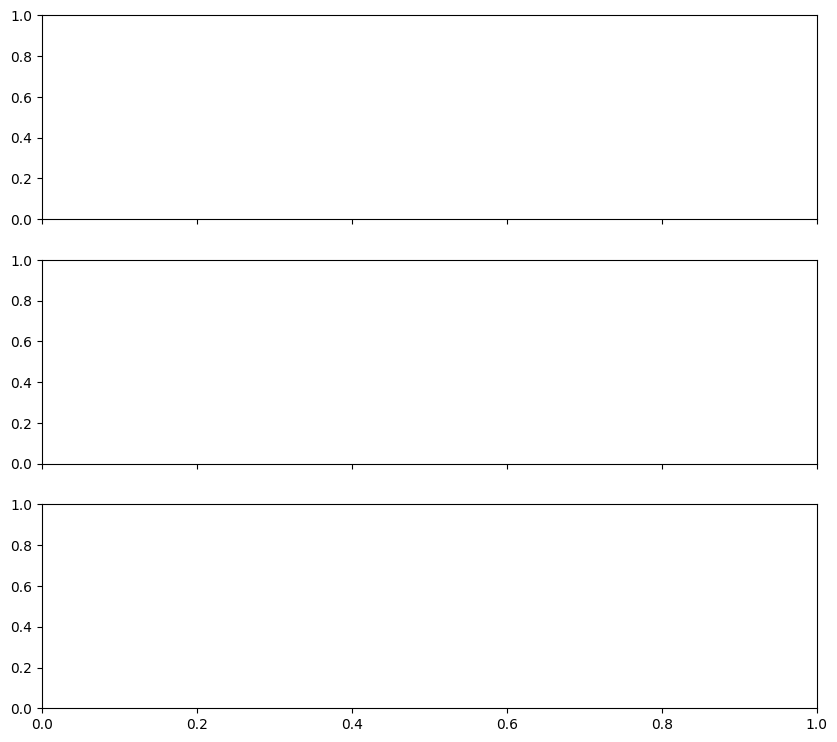

In [32]:
# Gráficas de las cuadraturas vs tiempo
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

In [33]:
axs[0].plot(ts_int, hs_int, 'b')
axs[0].set_ylabel('MARE  $h$')
axs[0].set_title('Cuadraturas del problema relativo Sol–Apophis')
axs[0].grid()

In [34]:
axs[1].plot(ts_int, epsilons, 'g')
axs[1].set_ylabel('ERE  $\\varepsilon$')
axs[1].grid()

In [35]:
axs[2].plot(ts_int, es_int, 'r')
axs[2].set_ylabel('$|\\vec{e}_L|$  (excentricidad)')
axs[2].set_xlabel('Tiempo (unidades Horizons desde 2026-04-20)')
axs[2].grid()

In [36]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>